In [21]:
import pandas as pd
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import numpy as np

In [22]:
SAMPLING_RATE = 240  # Hz
SKIP_TRIALS = {"Trial43.csv"}  # Different schema (34 channels, V/s units)
SENSOR_COLUMNS = ["25", "26", "27", "28", "29", "30", "31", "32"]

In [23]:
def load_raw_trial(filepath: str) -> pd.DataFrame:
    """
    Load a raw pitch trial CSV file.

    The raw files have TWO sections concatenated:
    Section 1 (voltage data - what we want):
    - Row 0: Device type ("Devices")
    - Row 1: Sampling rate (240)
    - Row 2: Metadata
    - Row 3: Column headers (Frame, Sub Frame, 25-32)
    - Row 4: Units (V)
    - Row 5+: Data

    Section 2 (derivative data - ignore):
    - Starts with another "Devices" line mid-file
    - Has 34 columns with V/s units

    We only read Section 1.
    """
    # First, read the file line by line to find where Section 2 starts
    with open(filepath, "r", encoding="utf-8-sig") as f:
        lines = f.readlines()

    # Find the second occurrence of "Devices" (start of Section 2)
    devices_indices = []
    for i, line in enumerate(lines):
        if line.strip().startswith("Devices"):
            devices_indices.append(i)

    # Determine how many lines to read (stop before Section 2)
    if len(devices_indices) >= 2:
        nrows = devices_indices[1] - 5  # Subtract header rows (0-4)
    else:
        nrows = None  # Read all if only one section

    # Read with header at row 3 (0-indexed), skip rows 0-2 and row 4 (units)
    df = pd.read_csv(filepath, header=3, skiprows=[4], nrows=nrows, encoding="utf-8-sig")

    # Clean column names (remove any whitespace)
    df.columns = df.columns.str.strip()

    df['time_step'] = np.arange(len(df)) / SAMPLING_RATE
    # Keep only Frame, Sub Frame, and sensor columns
    keep_cols = ["time_step"] + SENSOR_COLUMNS
    available_cols = [c for c in keep_cols if c in df.columns]
    df = df[available_cols].copy()

    # Drop rows with NaN values (from empty lines in raw data)
    df = df.dropna()

    return df

In [24]:
def convert_volt_to_ohms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert voltage readings to resistance (ohms) using the formula:
    R = (V * 1000) / (1-V/5)
    """
    for col in SENSOR_COLUMNS:
        if col in df.columns:
            df[col] = (df[col] * 1000) / (1 - df[col]/5)
    return df

In [25]:
df = load_raw_trial("pitch/good/unprocessed_data/Trial44.csv")
df

,time_step,25,26,27,28,29,30,31,32
0,0.000000,1.09436,0.524292,0.471802,1.92673,1.43372,1.05423,0.684814,0.589142
1,0.004167,1.09467,0.524445,0.471802,1.92688,1.43341,1.05362,0.684662,0.589142
2,0.008333,1.09482,0.524139,0.471649,1.92749,1.43219,1.05408,0.684357,0.589752
3,0.012500,1.09482,0.524750,0.471649,1.92673,1.43204,1.05347,0.684357,0.589447
4,0.016667,1.09497,0.525055,0.471954,1.92703,1.43234,1.05347,0.684357,0.589752
...,...,...,...,...,...,...,...,...,...
981,4.087500,1.64673,0.613556,0.600433,1.84097,1.27441,1.07529,0.664215,0.513763
982,4.091667,1.64673,0.613556,0.600281,1.84082,1.27396,1.07620,0.664062,0.513763
983,4.095833,1.64719,0.614014,0.600128,1.83990,1.27411,1.07590,0.663757,0.514069
984,4.100000,1.64352,0.612640,0.602875,1.84006,1.27319,1.07681,0.663300,0.514221


In [26]:
convert_volt_to_ohms(df)

,time_step,25,26,27,28,29,30,31,32
0,0.000000,1400.999580,585.708451,520.959993,3134.657873,2010.105768,1335.898950,793.493027,667.831519
1,0.004167,1401.507683,585.899402,520.959993,3135.054928,2009.496466,1334.919597,793.288961,667.831519
2,0.008333,1401.753568,585.517513,520.773456,3136.670019,2007.099593,1335.658097,792.879532,668.615461
3,0.012500,1401.753568,586.280096,520.773456,3134.657873,2006.805009,1334.678819,792.879532,668.223463
4,0.016667,1401.999472,586.660842,521.145324,3135.452022,2007.394202,1334.678819,792.879532,668.615461
...,...,...,...,...,...,...,...,...,...
981,4.087500,2455.409198,699.377446,682.377379,2913.821648,1710.346549,1369.897394,765.968562,572.599040
982,4.091667,2455.409198,699.377446,682.181067,2913.445894,1709.536130,1371.374688,765.765101,572.599040
983,4.095833,2456.432067,699.972595,681.983476,2911.142052,1709.806248,1370.887592,765.359552,572.979165
984,4.100000,2448.279150,698.187521,685.533161,2911.542624,1708.149865,1372.365346,764.752000,573.168005


<Axes: >

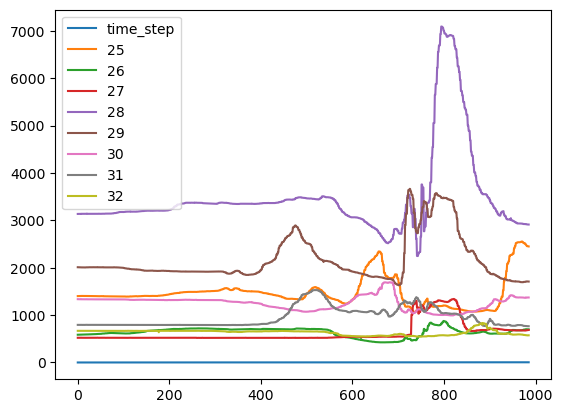

In [27]:
df.plot()